# Init

In [1]:
import os, pickle
from random import choice
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt

from aspire.env_config import env_var

from homog_utils import posn_from_xform

In [2]:
class TColor:
    """ Terminal Colors """
    # Source: https://stackoverflow.com/a/287944
    HEADER    = '\033[95m'
    OKBLUE    = '\033[94m'
    OKCYAN    = '\033[96m'
    OKGREEN   = '\033[92m'
    WARNING   = '\033[93m'
    FAIL      = '\033[91m'
    ENDC      = '\033[0m'
    BOLD      = '\033[1m'
    UNDERLINE = '\033[4m'

In [3]:
_DATA_DRIVE = "DATA_TANK"

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

In [4]:
########## SETUP ###################################################################################
_JSON_PATH  = "data/allData.txt"
_DATA_DRIVE = "DATA_TANK"
# _PLOT_DIR   = "/media/james/FILEPILE/EROM/data/plots/"
_PLOT_DIR   = "data/plots/"

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

longTestNames = [
    "Known Class & Known Pose", 
    "Sensed Class & Known Pose", 
    "Known Class & Sensed Pose", 
    "Sensed Class & Sensed Pose", 
]

# paths = [ f"/media/james/{_DATA_DRIVE}/2025-08_{test}" for test in tests ]
datasets = [
    [ f"/media/james/{_DATA_DRIVE}/2025-08B_{test}" for test in tests ],
    [ f"/media/james/{_DATA_DRIVE}/RWB_2025-09_{test}" for test in tests ],
]

dataLabels = ["RGB", "RBW",]
datNamLong = {
    "RGB": "Red-Green-Blue", 
    "RBW": "Red-Black-White",
}

fNames = [ f"{_PLOT_DIR}{test}" for test in tests  ]

plotExt = ".pdf"

pkls = deque()

for iii, paths in enumerate( datasets ):
    setNam = dataLabels[iii]
    suffix = "_" + setNam
    skip   = False

    for ii, test in enumerate( tests ):
        ##### Init ################################################################
        path     = paths[ii]
        fName    = fNames[ii]
        longTNam = longTestNames[ii]

        ##### Load ################################################################
        try:
            pkls.extend( [os.path.join( path, item ) for item in os.listdir( path ) if ".pkl" in f"{item}".lower()] )
        except FileNotFoundError as e:
            print( f"\n404, SKIP THIS TEST: {e}\n" )
            skip = True
            continue

# "Ground Truth" Annotator

In [5]:
from State import OCV_State_Tracker
ocvTracker = OCV_State_Tracker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


# Load File(s)

In [6]:
_EXP_INDEX = 0 # 130
_SAFE_POSN = np.array( [-0.25199, -0.26192, 0.47106,] ) 

In [7]:
print( f"Found {len(pkls)} files!" ) 
pklFile = pkls[ _EXP_INDEX ]

data = list()
try:
    with open( pklFile, 'rb' ) as f:
        data = pickle.load( f )
        print( f"LOAD SUCCESS: {pklFile}" )
except EOFError as e:
    print( f"LOAD ERROR: {e}" )

Found 163 files!
LOAD SUCCESS: /media/james/DATA_TANK/2025-08B_KC-KP/EROM-Memories_08-25-2025_11-18-58.pkl


In [8]:
from magpie_control.ur5 import _CAMERA_XFORM

def camPose_from_effPose( effPose : np.ndarray ):
    """ Get the camera pose given the effector pose """
    return np.dot( effPose, _CAMERA_XFORM )

### 1. Object Search ###
shotPoses = list()


MESSAGE: RobotState


MESSAGE: RobotState


MESSAGE: Task Start


MESSAGE: Performance


MESSAGE: Performance


MESSAGE: BGN: Phase 1

There are 0 RAY observations
There 0 loci to evaluate!
Last Scene: []

MESSAGE: Performance


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.554  0.169  0.258]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 17780 points!
Block mask is 0.18694561620006875 away!
Span is [169, 167]
Arc is [0.23760718511178358, 0.19127717771075356]
Scale is [1.116 0.897] * 0.04
Block mask of 44 points!
MASK FOUND for redBlock!


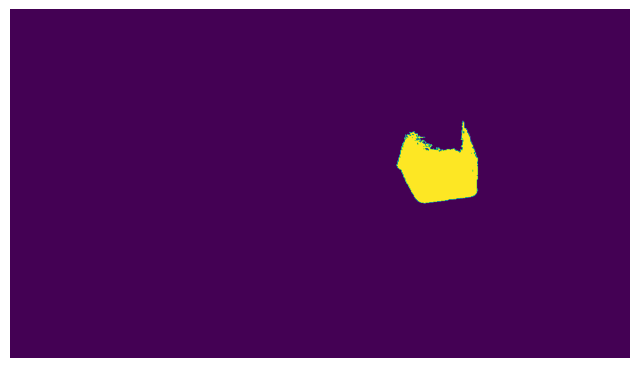

Shoot a ray through a mask of shape (720, 1280)
Block mask of 13627 points!
Block mask is 0.25269994409302104 away!
Span is [137, 141]
Arc is [0.19261647550481864, 0.16149749734860028]
Scale is [1.221 1.022] * 0.04
Block mask of 895 points!
Block mask of 474 points!
MASK FOUND for grnBlock!


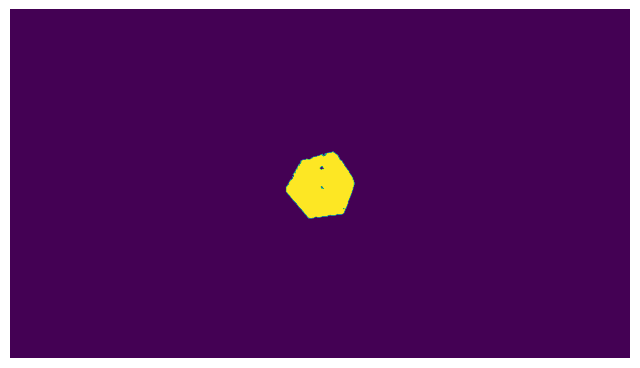

Shoot a ray through a mask of shape (720, 1280)
Block mask of 7472 points!
Block mask of 7091 points!
Block mask is 0.3113407050038192 away!
Span is [105, 124]
Arc is [0.14762576589785373, 0.14202616788103858]
Scale is [1.151 1.107] * 0.04
Block mask of 1744 points!
Block mask of 1002 points!
Block mask of 703 points!
Block mask of 563 points!
Block mask of 527 points!
Block mask of 527 points!
Block mask of 454 points!
MASK FOUND for bluBlock!


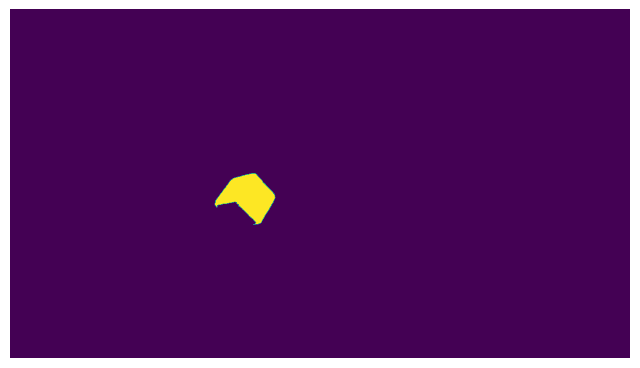

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.196 -0.34   0.275]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 6674 points!
Block mask is 0.33175007416453833 away!
Span is [102, 95]
Arc is [0.14340788687220074, 0.10881037055402148]
Scale is [1.191 0.903] * 0.04
Block mask of 12 points!
MASK FOUND for redBlock!


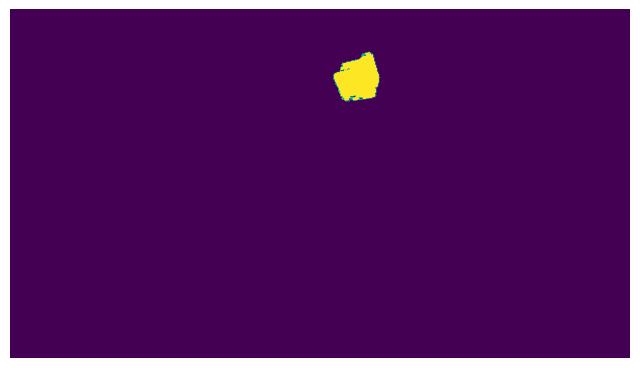

Shoot a ray through a mask of shape (720, 1280)
Block mask of 10295 points!
Block mask is 0.2765756773964596 away!
Span is [117, 120]
Arc is [0.16449728200046557, 0.13744467859455345]
Scale is [1.14  0.952] * 0.04
Block mask of 847 points!
Block mask of 380 points!
MASK FOUND for grnBlock!


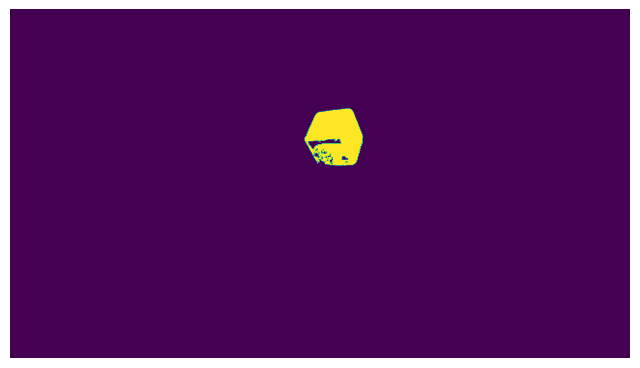

Shoot a ray through a mask of shape (720, 1280)
Block mask of 46193 points!
Block mask is 0.39075374310786126 away!
Span is [551, 290]
Arc is [0.7746837810449274, 0.3321579732701708]
Scale is [7.97  3.275] * 0.04
Block mask of 17462 points!
Block mask is 0.22446767540350432 away!
Span is [145, 158]
Arc is [0.20386415290655988, 0.18096882681616205]
Scale is [1.148 1.018] * 0.04
Block mask of 690 points!
Block mask is 0.39128391431725545 away!
Span is [46, 61]
Arc is [0.0646741450600121, 0.069867711618898]
Scale is [0.633 0.684] * 0.04
Block mask of 545 points!
Block mask is 0.38611248611310206 away!
Span is [51, 51]
Arc is [0.07170394343610037, 0.05841398840268521]
Scale is [0.692 0.564] * 0.04
Block mask of 491 points!
MASK FOUND for bluBlock!


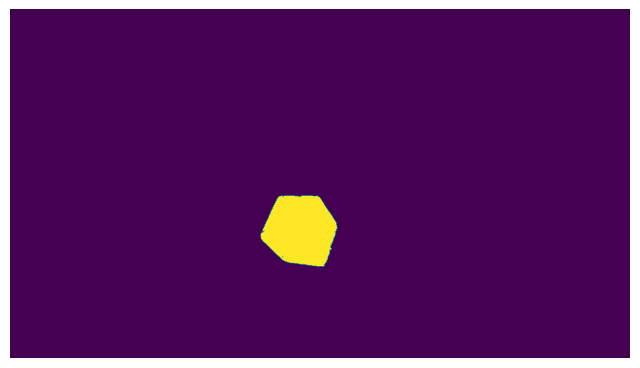

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.196 -0.34   0.275]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 7187 points!
Block mask is 0.33720818118772644 away!
Span is [102, 95]
Arc is [0.14340788687220074, 0.10881037055402148]
Scale is [1.211 0.918] * 0.04
Block mask of 4 points!
MASK FOUND for redBlock!


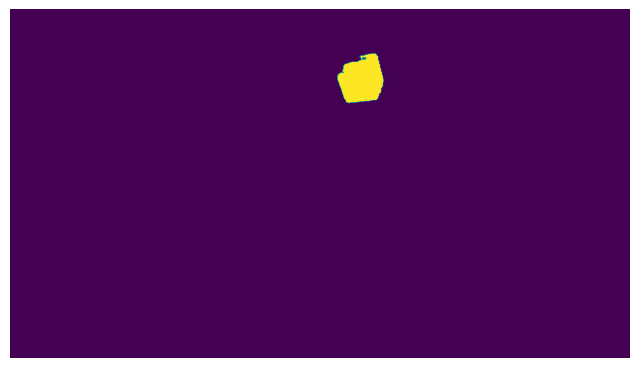

Shoot a ray through a mask of shape (720, 1280)
Block mask of 9542 points!
Block mask is 0.2780802381745503 away!
Span is [118, 119]
Arc is [0.16590324167568324, 0.13629930627293219]
Scale is [1.156 0.949] * 0.04
Block mask of 692 points!
Block mask of 465 points!
MASK FOUND for grnBlock!


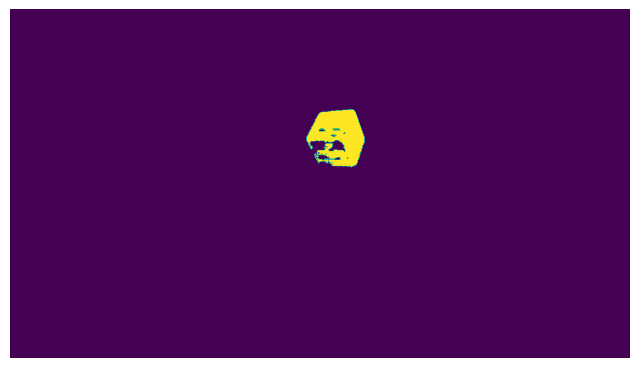

Shoot a ray through a mask of shape (720, 1280)
Block mask of 24691 points!
Block mask is 0.3611612297921478 away!
Span is [354, 179]
Arc is [0.49770972502704963, 0.20502164557020888]
Scale is [4.589 1.858] * 0.04
Block mask of 17455 points!
Block mask is 0.22230286017961845 away!
Span is [148, 158]
Arc is [0.20808203193221286, 0.18096882681616205]
Scale is [1.161 1.009] * 0.04
Block mask of 865 points!
Block mask is 0.35533350336344605 away!
Span is [51, 56]
Arc is [0.07170394343610037, 0.0641408500107916]
Scale is [0.637 0.57 ] * 0.04
Block mask of 531 points!
Block mask is 0.49753332138061523 away!
Span is [125, 79]
Arc is [0.1757449594022068, 0.09048441340808103]
Scale is [2.192 1.126] * 0.04
Block mask of 517 points!
Block mask of 511 points!
Block mask is 0.42161270410347357 away!
Span is [38, 37]
Arc is [0.05342646765827086, 0.042378775899987314]
Scale is [0.563 0.447] * 0.04
Block mask of 206 points!
MASK FOUND for bluBlock!


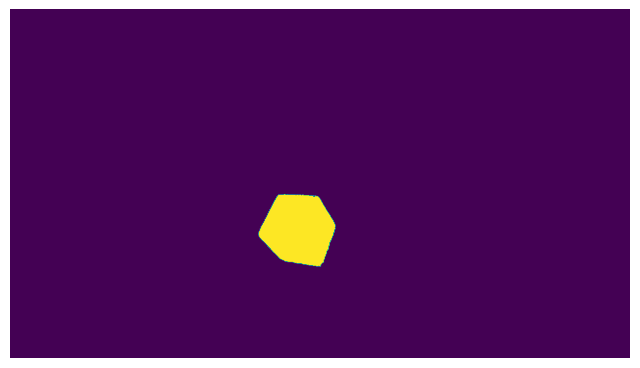

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: memory


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1


MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2


MESSAGE: Performance


MESSAGE: Validate Goal State


MESSAGE: BGN: Phase 3


MESSAGE: Annotation


MESSAGE: END: Phase 3


MESSAGE: Performance


MESSAGE: BGN: Phase 4


MESSAGE: BT BEGIN: 1756142439.1435277


MESSAGE: RobotState

Moved to [-0.196 -0.34   0.275]

MESSAGE: Behavior: Move_Arm, Status.RUNNING


MESSAGE: RobotState

Moved to [-0.2   -0.335  0.35 ]

MESSAGE: RobotState

Moved to [-0.384 -0.071  0.35 ]

MESSAGE: RobotState

Moved to [-0.384 -0.071  0.25 ]

MESSAGE: RobotState

Moved to [-0.384 -0.071  0.35 ]

MESSAGE: RobotState

Moved to [-0.204 -0.295  0.35 ]

MESSAGE: Behavior: Open_Gripper, Status.SUCCESS


MESSAGE: BT END: Status.SUCCESS


MESSAGE: Action Su

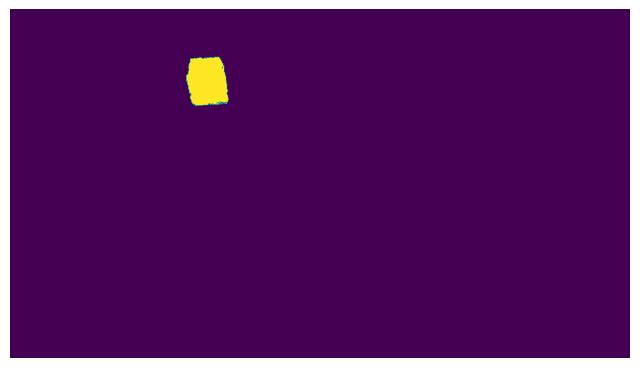

Shoot a ray through a mask of shape (720, 1280)
Block mask of 14701 points!
Block mask is 0.18003851718111247 away!
Span is [96, 227]
Arc is [0.13497212882089482, 0.25999951700803026]
Scale is [0.608 1.177] * 0.04
Block mask of 402 points!
MASK FOUND for grnBlock!


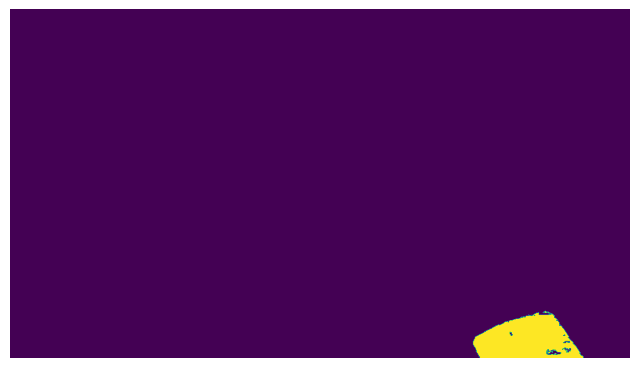

Shoot a ray through a mask of shape (720, 1280)
Block mask of 19508 points!
Block mask is 0.20405378365117754 away!
Span is [162, 143]
Arc is [0.22776546738526002, 0.16378824199184286]
Scale is [1.167 0.837] * 0.04
Block mask of 2562 points!
Block mask of 1373 points!
Block mask is 0.2920681364252826 away!
Span is [139, 111]
Arc is [0.19542839485525396, 0.12713632769996194]
Scale is [1.432 0.93 ] * 0.04
Block mask of 733 points!
Block mask is 0.2901398779010493 away!
Span is [32, 33]
Arc is [0.04499070960696494, 0.0377972866135022]
Scale is [0.326 0.274] * 0.04
Block mask of 525 points!
Block mask of 377 points!
MASK FOUND for bluBlock!


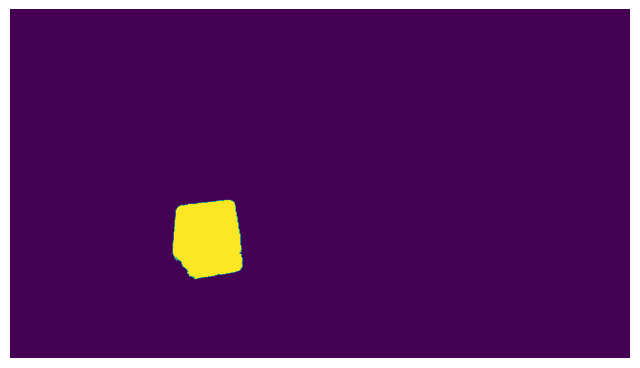

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.51  -0.028  0.311]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 18892 points!
Block mask is 0.16310912379307616 away!
Span is [213, 133]
Arc is [0.2994694108213604, 0.1523345187756301]
Scale is [1.23  0.622] * 0.04
Block mask of 5 points!
MASK FOUND for redBlock!


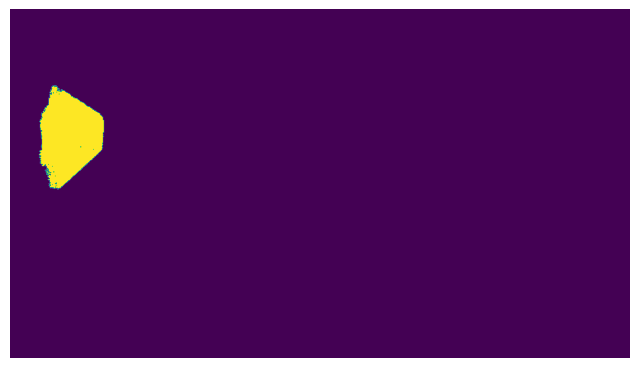

Shoot a ray through a mask of shape (720, 1280)
Block mask of 7704 points!
Block mask is 0.3501835474407241 away!
Span is [102, 102]
Arc is [0.14340788687220074, 0.11682797680537042]
Scale is [1.258 1.024] * 0.04
Block mask of 841 points!
Block mask of 517 points!
Block mask is 0.3229174538264199 away!
Span is [18, 79]
Arc is [0.025307274153917782, 0.09048441340808103]
Scale is [0.204 0.731] * 0.04
Block mask of 455 points!
MASK FOUND for grnBlock!


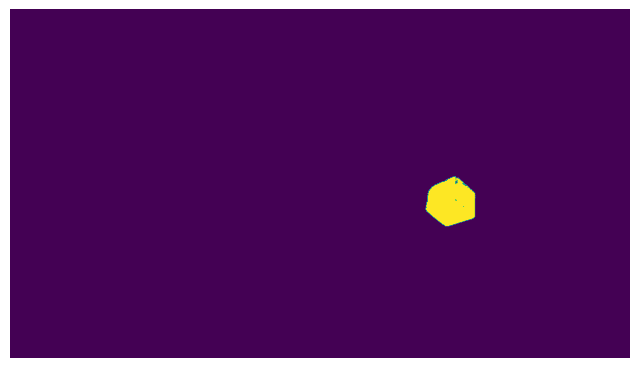

Shoot a ray through a mask of shape (720, 1280)
Block mask of 20388 points!
Block mask is 0.20623315269393908 away!
Span is [164, 174]
Arc is [0.2305773867356953, 0.19929478396210248]
Scale is [1.194 1.031] * 0.04
Block mask of 7587 points!
Block mask of 3735 points!
Block mask of 2264 points!
Block mask of 2025 points!
Block mask of 1974 points!
Block mask of 1795 points!
Block mask of 1445 points!
Block mask of 741 points!
Block mask of 666 points!
Block mask of 630 points!
Block mask of 628 points!
Block mask of 502 points!
Block mask of 490 points!
MASK FOUND for bluBlock!


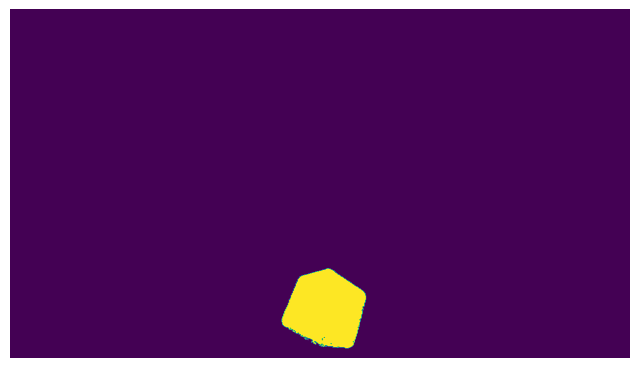

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.51  -0.028  0.311]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 30051 points!
Block mask is 0.16542318988868354 away!
Span is [150, 251]
Arc is [0.21089395128264815, 0.28748845272694096]
Scale is [0.875 1.197] * 0.04
Block mask of 3 points!
MASK FOUND for redBlock!


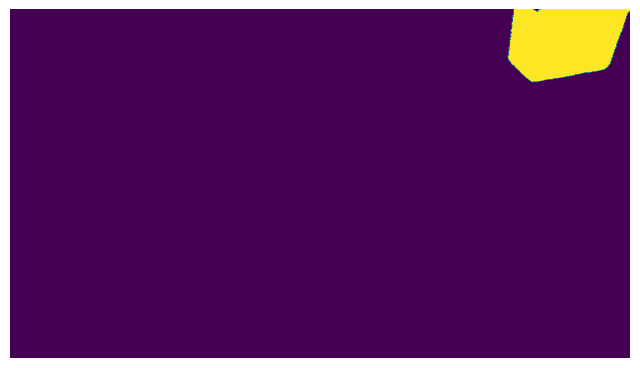

Shoot a ray through a mask of shape (720, 1280)
Block mask of 7886 points!
Block mask is 0.34489873583411296 away!
Span is [95, 107]
Arc is [0.13356616914567715, 0.12255483841347682]
Scale is [1.153 1.058] * 0.04
Block mask of 69 points!
MASK FOUND for grnBlock!


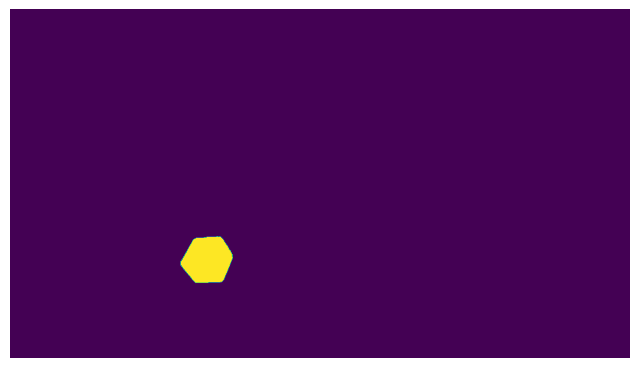

Shoot a ray through a mask of shape (720, 1280)
Block mask of 20251 points!
Block mask is 0.20338736835358157 away!
Span is [162, 171]
Arc is [0.22776546738526002, 0.1958586669972387]
Scale is [1.163 0.999] * 0.04
Block mask of 676 points!
Block mask is 0.36754269826979863 away!
Span is [24, 175]
Arc is [0.033743032205223705, 0.20044015628372377]
Scale is [0.31  1.848] * 0.04
Block mask of 46 points!
MASK FOUND for bluBlock!


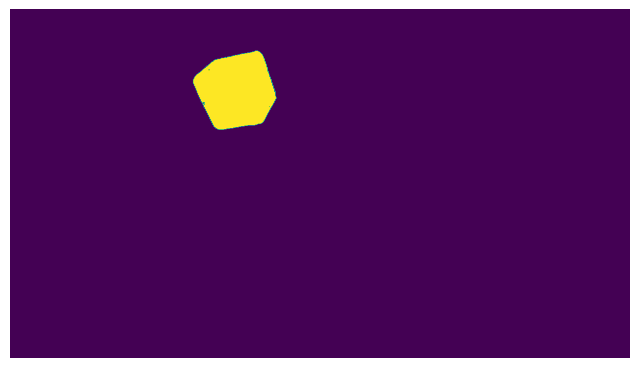

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: memory


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1


MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2


MESSAGE: Performance


MESSAGE: Validate Goal State


MESSAGE: BGN: Phase 3


MESSAGE: Annotation


MESSAGE: END: Phase 3


MESSAGE: Performance


MESSAGE: BGN: Phase 4


MESSAGE: BT BEGIN: 1756142531.1328485


MESSAGE: RobotState

Moved to [-0.51  -0.028  0.311]

MESSAGE: Behavior: Move_Arm, Status.RUNNING


MESSAGE: RobotState

Moved to [-0.514 -0.023  0.35 ]

MESSAGE: RobotState

Moved to [-0.384  0.034  0.35 ]

MESSAGE: RobotState

Moved to [-0.384  0.034  0.25 ]

MESSAGE: RobotState

Moved to [-0.384  0.034  0.35 ]

MESSAGE: RobotState

Moved to [-0.204 -0.294  0.35 ]

MESSAGE: Behavior: Open_Gripper, Status.SUCCESS


MESSAGE: BT END: Status.SUCCESS


MESSAGE: Action Su

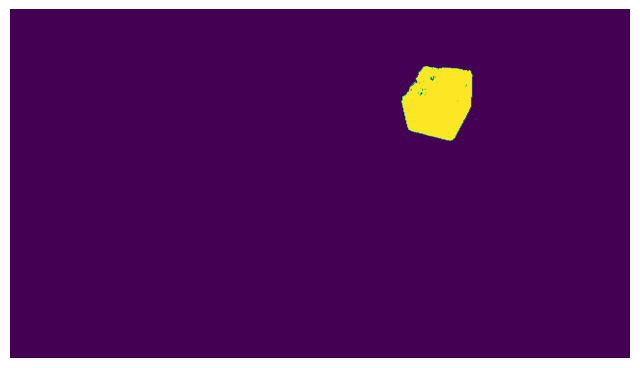

Shoot a ray through a mask of shape (720, 1280)
Block mask of 5565 points!
Block mask is 0.25138782414240635 away!
Span is [81, 128]
Arc is [0.11388273369263001, 0.1466076571675237]
Scale is [0.716 0.923] * 0.04
Block mask of 532 points!
Block mask of 266 points!
MASK FOUND for grnBlock!


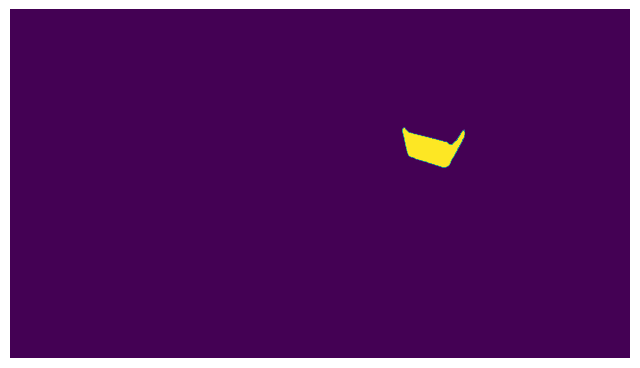

Shoot a ray through a mask of shape (720, 1280)
Block mask of 11236 points!
Block mask is 0.2753701993589455 away!
Span is [131, 141]
Arc is [0.18418071745351272, 0.16149749734860028]
Scale is [1.272 1.114] * 0.04
Block mask of 1426 points!
Block mask of 1106 points!
Block mask of 358 points!
MASK FOUND for bluBlock!


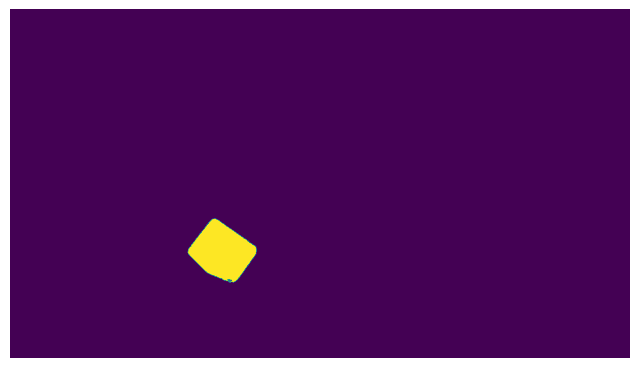

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [ 0.113 -0.367  0.247]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 12905 points!
Block mask is 0.23960818031827721 away!
Span is [117, 133]
Arc is [0.16449728200046557, 0.1523345187756301]
Scale is [0.988 0.914] * 0.04
Block mask of 70 points!
MASK FOUND for redBlock!


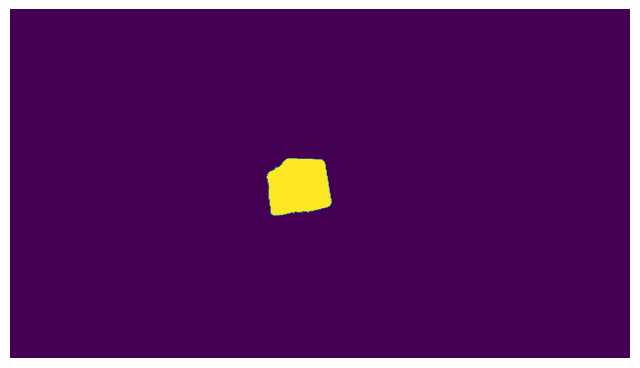

Shoot a ray through a mask of shape (720, 1280)
Block mask of 6946 points!
Block mask is 0.26918053438733913 away!
Span is [96, 97]
Arc is [0.13497212882089482, 0.11110111519726404]
Scale is [0.91  0.748] * 0.04
Block mask of 1686 points!
Block mask of 748 points!
Block mask of 680 points!
Block mask of 616 points!
Block mask of 524 points!
Block mask of 454 points!
MASK FOUND for grnBlock!


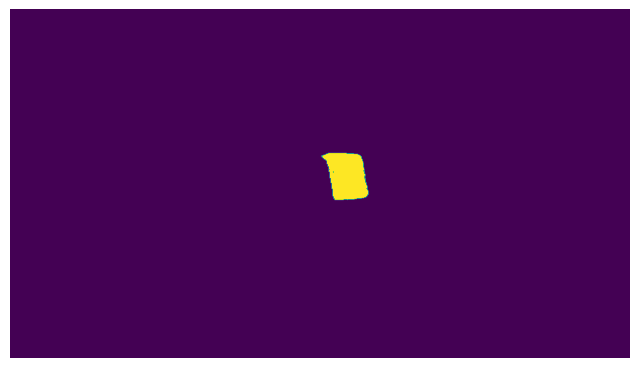

Shoot a ray through a mask of shape (720, 1280)
Block mask of 34858 points!
Block mask of 6583 points!
Block mask of 4094 points!
Block mask is 0.43717709218793815 away!
Span is [75, 74]
Arc is [0.10544697564132408, 0.08475755179997463]
Scale is [1.154 0.927] * 0.04
Block mask of 1403 points!
Block mask of 1379 points!
Block mask of 888 points!
Block mask of 869 points!
Block mask of 336 points!
MASK FOUND for bluBlock!


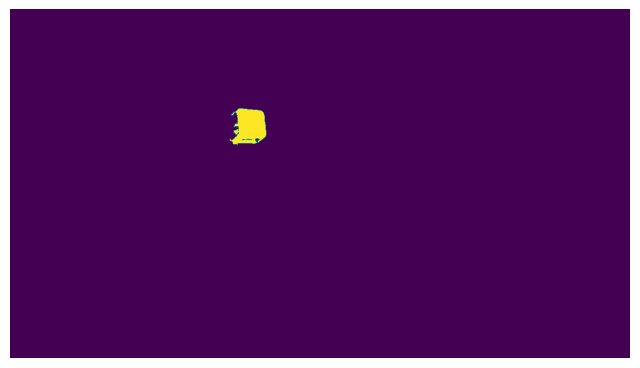

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [ 0.113 -0.367  0.247]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 12605 points!
Block mask is 0.2378173050111536 away!
Span is [132, 137]
Arc is [0.18558667712873037, 0.1569160080621152]
Scale is [1.107 0.935] * 0.04
Block mask of 7 points!
MASK FOUND for redBlock!


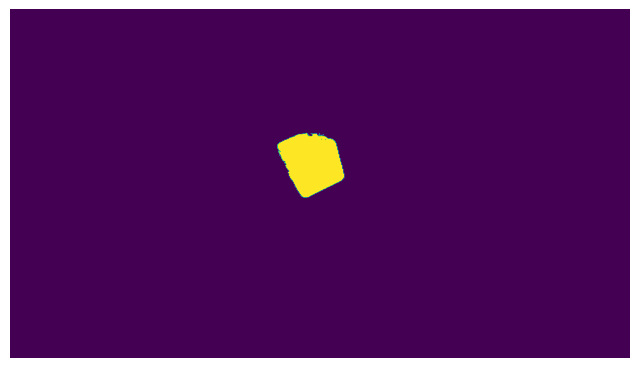

Shoot a ray through a mask of shape (720, 1280)
Block mask of 7054 points!
Block mask is 0.2597178535843581 away!
Span is [113, 103]
Arc is [0.15887344329959494, 0.11797334912699171]
Scale is [1.034 0.767] * 0.04
Block mask of 794 points!
Block mask of 656 points!
Block mask of 396 points!
MASK FOUND for grnBlock!


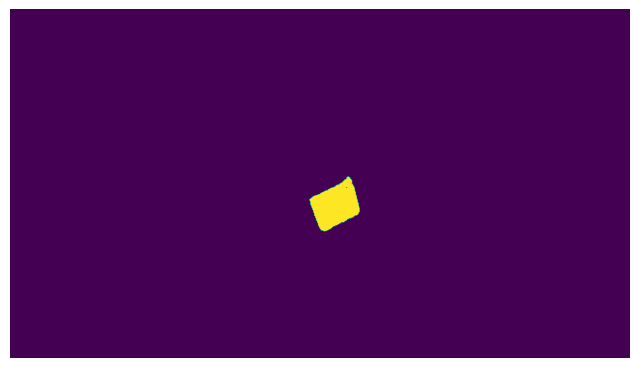

Shoot a ray through a mask of shape (720, 1280)
Block mask of 30014 points!
Block mask is 0.43093574784947114 away!
Span is [228, 347]
Arc is [0.3205588059496252, 0.39744419560258376]
Scale is [3.483 4.339] * 0.04
Block mask of 4314 points!
Block mask of 3652 points!
Block mask is 0.4997999966144562 away!
Span is [110, 119]
Arc is [0.154655564273942, 0.13629930627293219]
Scale is [1.936 1.706] * 0.04
Block mask of 2649 points!
Block mask of 2072 points!
Block mask of 912 points!
Block mask of 890 points!
Block mask is 0.4784939777420228 away!
Span is [61, 37]
Arc is [0.08576354018827691, 0.042378775899987314]
Scale is [1.027 0.507] * 0.04
Block mask of 507 points!
Block mask of 411 points!
MASK FOUND for bluBlock!


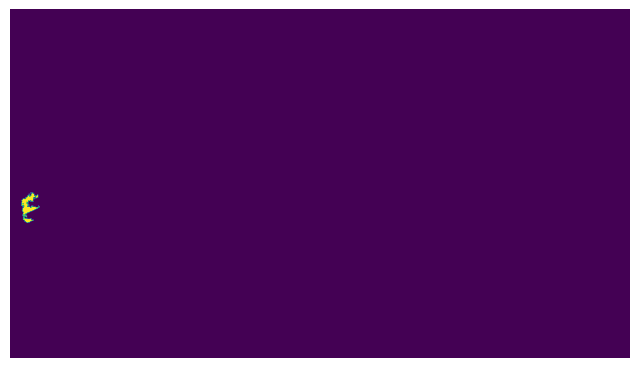

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: memory


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1


MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2


MESSAGE: Performance


MESSAGE: Validate Goal State


MESSAGE: BGN: Phase 3


MESSAGE: Annotation


MESSAGE: END: Phase 3


MESSAGE: Performance


MESSAGE: BGN: Phase 4


MESSAGE: BT BEGIN: 1756142677.5989308


MESSAGE: RobotState

Moved to [ 0.113 -0.367  0.247]

MESSAGE: Behavior: Move_Arm, Status.RUNNING


MESSAGE: RobotState

Moved to [ 0.109 -0.362  0.35 ]

MESSAGE: RobotState

Moved to [-0.384 -0.169  0.35 ]

MESSAGE: RobotState

Moved to [-0.384 -0.168  0.25 ]

MESSAGE: RobotState

Moved to [-0.384 -0.168  0.35 ]

MESSAGE: RobotState

Moved to [-0.204 -0.295  0.35 ]

MESSAGE: Behavior: Open_Gripper, Status.SUCCESS


MESSAGE: BT END: Status.SUCCESS


MESSAGE: Action Su

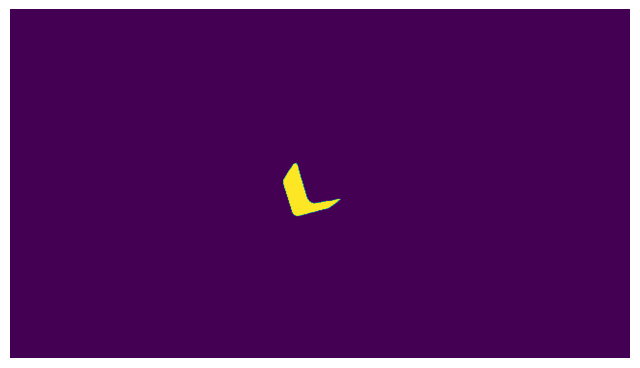

Shoot a ray through a mask of shape (720, 1280)
Block mask of 1780 points!
Block mask is 0.30766908025942774 away!
Span is [72, 101]
Arc is [0.10122909661567113, 0.11568260448374915]
Scale is [0.779 0.891] * 0.04
Block mask of 314 points!
MASK FOUND for grnBlock!


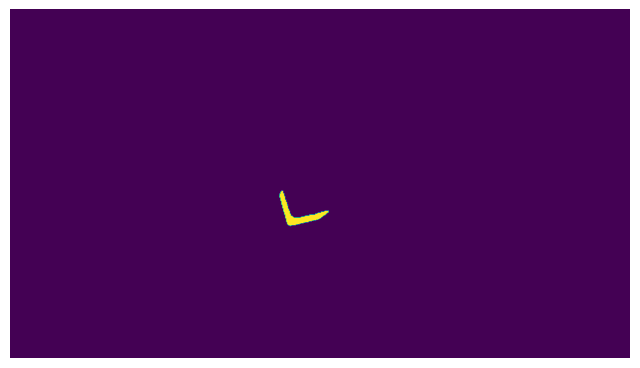

Shoot a ray through a mask of shape (720, 1280)
Block mask of 15031 points!
Block mask is 0.23155457269315724 away!
Span is [137, 145]
Arc is [0.19261647550481864, 0.1660789866350854]
Scale is [1.118 0.964] * 0.04
Block mask of 9929 points!
Block mask of 1312 points!
Block mask of 957 points!
Block mask is 0.369411392769968 away!
Span is [177, 52]
Arc is [0.24885486251352482, 0.059559360724306495]
Scale is [2.31 0.55] * 0.04
Block mask of 907 points!
Block mask of 586 points!
Block mask of 393 points!
MASK FOUND for bluBlock!


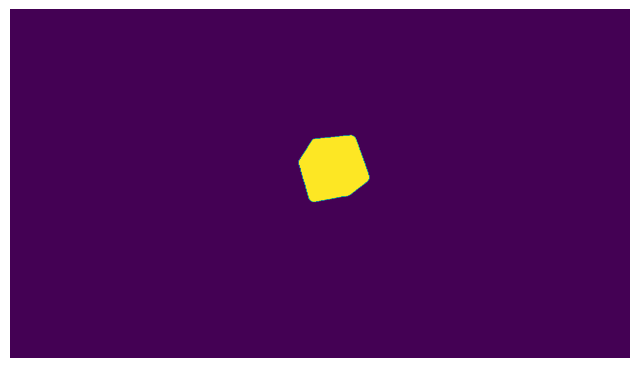

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.424 -0.051  0.262]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 9258 points!
Block mask is 0.2593763354936205 away!
Span is [122, 135]
Arc is [0.17152708037655381, 0.15462526341887264]
Scale is [1.115 1.005] * 0.04
Block mask of 1 points!
MASK FOUND for redBlock!


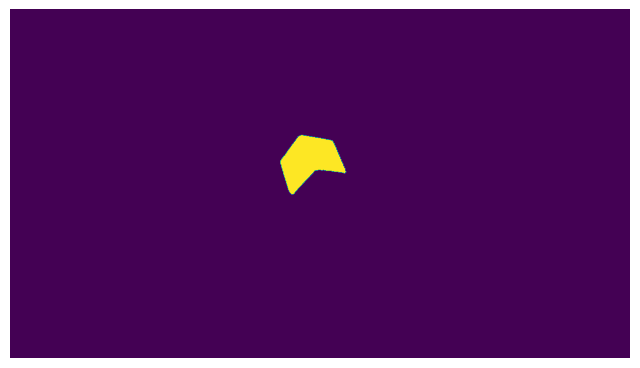

Shoot a ray through a mask of shape (720, 1280)
Block mask of 8274 points!
Block mask is 0.27615922211734034 away!
Span is [115, 126]
Arc is [0.16168536265003022, 0.1443169125242811]
Scale is [1.119 0.998] * 0.04
Block mask of 1201 points!
Block mask of 642 points!
Block mask of 507 points!
Block mask is 0.22408934222640842 away!
Span is [39, 33]
Arc is [0.05483242733348852, 0.0377972866135022]
Scale is [0.307 0.212] * 0.04
Block mask of 474 points!
MASK FOUND for grnBlock!


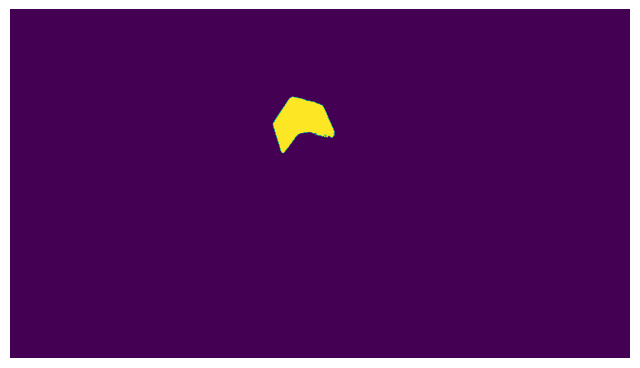

Shoot a ray through a mask of shape (720, 1280)
Block mask of 12757 points!
Block mask is 0.23876572345860606 away!
Span is [132, 149]
Arc is [0.18558667712873037, 0.17066047592157055]
Scale is [1.111 1.021] * 0.04
Block mask of 8893 points!
Block mask is 0.4821109054680157 away!
Span is [113, 148]
Arc is [0.15887344329959494, 0.16951510359994926]
Scale is [1.919 2.048] * 0.04
Block mask of 2238 points!
Block mask is 0.29672932624816895 away!
Span is [68, 64]
Arc is [0.0956052579148005, 0.07330382858376185]
Scale is [0.71  0.544] * 0.04
Block mask of 2014 points!
Block mask of 949 points!
Block mask of 910 points!
Block mask of 771 points!
Block mask of 724 points!
Block mask of 698 points!
Block mask of 669 points!
Block mask of 669 points!
Block mask is 0.22701795657951676 away!
Span is [56, 35]
Arc is [0.07873374181218865, 0.040088031256744754]
Scale is [0.447 0.228] * 0.04
Block mask of 586 points!
Block mask of 555 points!
Block mask of 507 points!
Block mask of 479 points!
MASK F

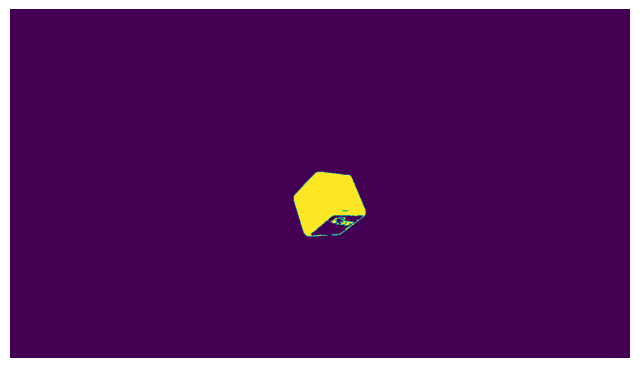

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: Observation END


MESSAGE: RobotState


MESSAGE: RobotState

Moved to [-0.424 -0.051  0.262]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

Block mask of 9332 points!
Block mask is 0.25700248141322285 away!
Span is [136, 131]
Arc is [0.191210515829601, 0.1500437741323875]
Scale is [1.232 0.966] * 0.04
MASK FOUND for redBlock!


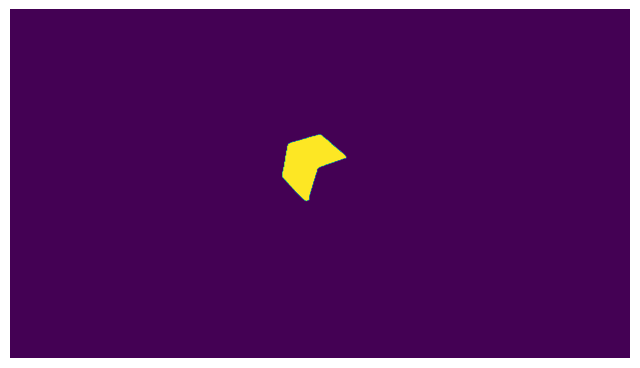

Shoot a ray through a mask of shape (720, 1280)
Block mask of 8318 points!
Block mask is 0.27706138036584343 away!
Span is [125, 123]
Arc is [0.1757449594022068, 0.1408807955594173]
Scale is [1.22  0.977] * 0.04
Block mask of 3349 points!
Block mask of 1794 points!
Block mask of 1365 points!
Block mask is 0.2178782111217263 away!
Span is [45, 108]
Arc is [0.06326818538479445, 0.12370021073509811]
Scale is [0.345 0.675] * 0.04
Block mask of 1242 points!
Block mask is 0.22429854781539352 away!
Span is [53, 69]
Arc is [0.07451586278653569, 0.07903069019186824]
Scale is [0.418 0.443] * 0.04
Block mask of 993 points!
Block mask is 0.2324066162109375 away!
Span is [54, 61]
Arc is [0.07592182246175333, 0.069867711618898]
Scale is [0.441 0.406] * 0.04
Block mask of 964 points!
Block mask of 633 points!
Block mask of 452 points!
MASK FOUND for grnBlock!


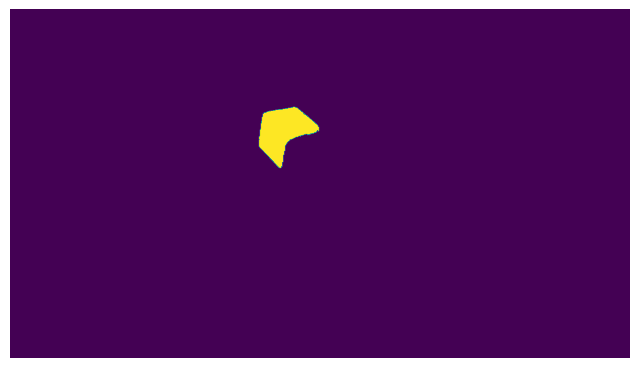

Shoot a ray through a mask of shape (720, 1280)
Block mask of 12966 points!
Block mask is 0.2366592460393075 away!
Span is [152, 151]
Arc is [0.21370587063308344, 0.17295122056481307]
Scale is [1.269 1.026] * 0.04
Block mask of 2608 points!
Block mask is 0.2771308574270695 away!
Span is [64, 71]
Arc is [0.08998141921392988, 0.08132143483511078]
Scale is [0.624 0.564] * 0.04
Block mask of 2054 points!
Block mask of 1932 points!
Block mask of 700 points!
Block mask of 686 points!
Block mask is 0.22894364657779803 away!
Span is [28, 51]
Arc is [0.03936687090609432, 0.05841398840268521]
Scale is [0.225 0.334] * 0.04
Block mask of 661 points!
Block mask of 651 points!
Block mask of 610 points!
Block mask of 555 points!
Block mask of 507 points!
Block mask of 423 points!
MASK FOUND for bluBlock!


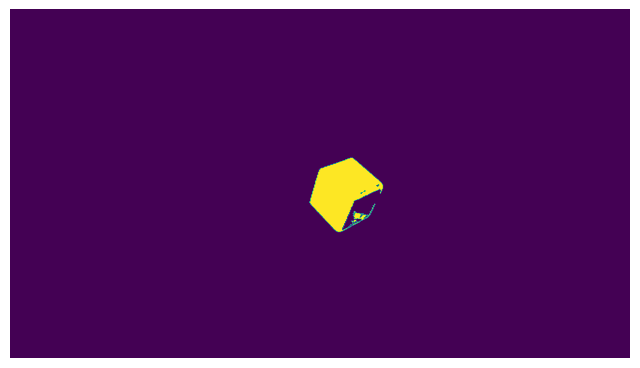

Shoot a ray through a mask of shape (720, 1280)

Added 3 rays!



MESSAGE: memory


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1


MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2


MESSAGE: Performance


MESSAGE: Believe Success, Iteration 4: Noisy facts indicate goal was met!
[('Base', 'table'), ('Waypoint', <ObjPose 0, Vec: [-0.2 -0.3 0.02] >), ('PoseAbove', <ObjPose 0, Vec: [-0.2 -0.3 0.02] >, 'table'), ('Graspable', 'redBlock'), ('GraspObj', 'redBlock', <ObjPose 0, Vec: [-0.2 -0.3 0.02] >), ('Graspable', 'grnBlock'), ('GraspObj', 'grnBlock', <ObjPose 0, Vec: [-0.2 -0.3 0.02] >), ('Graspable', 'bluBlock'), ('GraspObj', 'bluBlock', <ObjPose 189, Vec: [-0.2 -0.3 0.1] >), ('Waypoint', <ObjPose 189, Vec: [-0.2 -0.3 0.1] >), ('HandEmpty',), ('GraspObj', 'grnBlock', <ObjPose 0, Vec: [-0.2 -0.3 0.02] >), ('Supported', 'redBlock', 'grnBlock'), ('Blocked', '

In [9]:
for i, datum in enumerate( data ):
    dtmMsg = datum['msg']
    dtmDat = datum['data']

    print( f"\n{TColor.OKBLUE}MESSAGE: {dtmMsg}{TColor.ENDC}\n" ) 

    ##### General State ###################################

    if "RobotState" in dtmMsg:
        pose_t = np.array( dtmDat['pose'] )
        posn_t = posn_from_xform( pose_t )
        if np.linalg.norm( posn_t - _SAFE_POSN ) > env_var("_ACCEPT_POSN_ERR"):
            print( f"Moved to {posn_t}" )
            shotPoses.append( pose_t )  

    
    ##### Phase 1: Perception #############################
    
    if "BGN: Phase 1" in dtmMsg:
        # ASSUMPTION: PHASE 1 MESSAGE SENT ONLY ONCE PER STEP, See `p1pp2`
        res = ocvTracker.reconcile_scene()
        print( f"Last Scene: {res}" )
        ocvTracker.new_scene()
    
    if dtmMsg == "ObsMeta":
        # inpt = dtmDat['input']
        # hits = dtmDat['hits']
        # snap = inpt[ choice( list( inpt.keys() ) ) ]
        # # print( list( snap.keys() ) )
        # imag = snap['image']
        # dpth = snap['depth']
        # fig  = plt.figure()
        # plt.imshow( imag )
        # plt.close( fig )
        # fig = plt.figure()
        # plt.imshow( dpth )
        # plt.close( fig )
        # ocvTracker.TEST_FUNC( 'redBlock', imag )
        # res = ocvTracker.find_block_mask( 'redBlock', imag, dpth )
        ocvTracker.process_observation_data( dtmDat, ['redBlock','grnBlock','bluBlock',], camPose_from_effPose( shotPoses[-1] ) )
        
res = ocvTracker.reconcile_scene()
print( f"Last Scene: {res}" )
        